### Librerias y carga de info

In [120]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrices

import warnings
warnings.filterwarnings('ignore')

In [121]:
df= pd.read_excel('/content/SeoulBikeData.xlsx')#, sheet_name=1)

In [122]:
print(df.head()) #como se ve nuestro df

        Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0 2017-12-01                254     0             -5.2           37   
1 2017-12-01                204     1             -5.5           38   
2 2017-12-01                173     2             -6.0           39   
3 2017-12-01                107     3             -6.2           40   
4 2017-12-01                 78     4             -6.0           36   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   
2               1.0              2000                      -17.7   
3               0.9              2000                      -17.6   
4               2.3              2000                      -18.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0            0.0  Winter  No Holiday   
1     

In [123]:
df.info() # que tipo de variables tenemos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[ns]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(°C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(°C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   object        
 12  Holida

### Definición de modelo sin ninguna preparación

In [124]:
# Renombrar variables por temas de caracteres
df = df.rename(columns={
    'Rented Bike Count' : 'Rented_Bike_Count',
    'Temperature(°C)': 'Temperature',
    'Humidity(%)': 'Humidity',
    'Wind speed (m/s)': 'Wind_speed',
    'Visibility (10m)': 'Visibility',
    'Dew point temperature(°C)': 'Dew_point_temperature',
    'Solar Radiation (MJ/m2)': 'Solar_Radiation',
    'Rainfall(mm)': 'Rainfall',
    'Snowfall (cm)': 'Snowfall'
})

# Definir el modelo
y, X = dmatrices('Rented_Bike_Count ~ Hour + Temperature + Visibility + Solar_Radiation', data=df, return_type='dataframe')

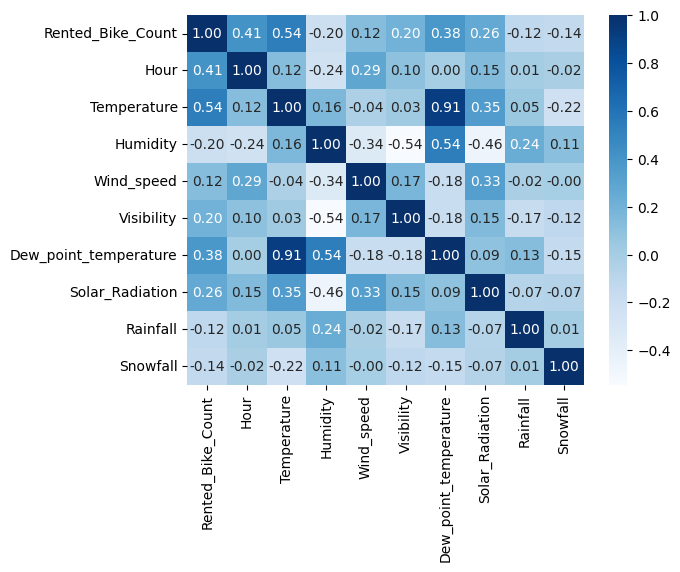

<Figure size 1000x800 with 0 Axes>

Rented_Bike_Count        1.000000
Temperature              0.538558
Hour                     0.410257
Dew_point_temperature    0.379788
Solar_Radiation          0.261837
Visibility               0.199280
Wind_speed               0.121108
Rainfall                -0.123074
Snowfall                -0.141804
Humidity                -0.199780
Name: Rented_Bike_Count, dtype: float64


In [125]:
# Seleccionar solo variables cuantitativas
quantitative_vars = df.select_dtypes(include=np.number).columns.tolist()
df_quantitative = df[quantitative_vars]

# Matriz de correlacion para analizar mejor las variables cuantitativas
correlacion = df_quantitative.corr()
sns.heatmap(correlacion, annot=True, cmap='Blues', fmt=".2f")
plt.figure(figsize=(10, 8))
plt.show()

rented_bike_corr = correlacion['Rented_Bike_Count']

# Analizar mejor cuales variables estan mejor correlacionadas para un analisis significativo
sorted_corr = rented_bike_corr.sort_values(ascending=False)

print(sorted_corr)

In [126]:
mod = sm.OLS(y, X)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:      Rented_Bike_Count   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     1666.
Date:                Sat, 29 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:56:19   Log-Likelihood:                -66621.
No. Observations:                8760   AIC:                         1.333e+05
Df Residuals:                    8755   BIC:                         1.333e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        -221.0267     15.890    -


###**Pruebas o supuestos del modelo**




*Normalidad de los errores*

In [127]:
# H0: Los errores tienen una distribución normal
from scipy.stats import shapiro  #Normalidad
stat, p = shapiro(res.resid)
print('Estadístico=%.3f, p=%.3f' % (stat, p))

Estadístico=0.967, p=0.000


*Heterocedasticidad  (Varianza de los residuos)*



In [128]:
# Ho: Hay homocedasticidad en los errores
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(res.resid, res.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(1024.2937515632277), 'LM-Test p-value': np.float64(1.9394545792598893e-220), 'F-Statistic': np.float64(289.81490205720525), 'F-Test p-value': np.float64(2.0271548495583836e-234)}


*Autocorrelacion de los residuos*

In [129]:
# DW:  Valor cercano intervalo 1.5 - 2.5
from statsmodels.stats.stattools import durbin_watson   #autocorrelacion
dw = durbin_watson(res.resid)
print('Durbin-Watson:', dw)


##( dw < 1.5 ) o ( dw > 2.5 ): Indica un problema potencialmente grave de autocorrelación.
##( 1.5 < dw < 2.5 ): Es probable que la autocorrelación no sea motivo de preocupación


Durbin-Watson: 0.4025031954275585


### Estandarizando las variables indepedientes

In [130]:
df_sin_y = df[['Hour' , 'Temperature' , 'Visibility' , 'Solar_Radiation']]

from sklearn.preprocessing import StandardScaler
# Estandarizar los datos

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sin_y)
df_scaled = pd.DataFrame(data=df_scaled, columns=['Hour' , 'Temperature' , 'Visibility' , 'Solar_Radiation' ])
df_scaled['Rented_Bike_Count'] = df['Rented_Bike_Count']
df_scaled


y1, X1 = dmatrices('Rented_Bike_Count  ~ Hour + Temperature + Visibility + Solar_Radiation', data=df_scaled, return_type='dataframe')

mod = sm.OLS(y1, X1)
res1 = mod.fit()
print(res1.summary())


                            OLS Regression Results                            
Dep. Variable:      Rented_Bike_Count   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     1666.
Date:                Sat, 29 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:56:19   Log-Likelihood:                -66621.
No. Observations:                8760   AIC:                         1.333e+05
Df Residuals:                    8755   BIC:                         1.333e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         704.6021      5.194    1

¿Que pasa cuando se estandariza tambien la variable independiente?

### Dividiendo el conjunto de datos en Train y Test

In [131]:
#Division de datos en train y test
from sklearn.model_selection import train_test_split
X = df_scaled[['Hour' , 'Temperature' , 'Visibility' , 'Solar_Radiation']]
y = df_scaled['Rented_Bike_Count']

X_train, X_test, y_train, y_test = train_test_split(X, y.values.reshape(-1,1),train_size = 0.8,random_state = 1234,shuffle = True)



In [132]:
X_train = sm.add_constant(X_train, prepend=True)
modelo = sm.OLS(endog = y_train, exog = X_train)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     1334.
Date:                Sat, 29 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:56:19   Log-Likelihood:                -53242.
No. Observations:                7008   AIC:                         1.065e+05
Df Residuals:                    7003   BIC:                         1.065e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             701.8453      5.762    1

In [133]:
X_test = sm.add_constant(X_test, prepend=True)
modelo = sm.OLS(endog = y_test, exog = X_test)
modelo = modelo.fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     333.7
Date:                Sat, 29 Mar 2025   Prob (F-statistic):          1.71e-213
Time:                        01:56:19   Log-Likelihood:                -13375.
No. Observations:                1752   AIC:                         2.676e+04
Df Residuals:                    1747   BIC:                         2.679e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             715.5186     11.978     

### Prueba de consistencia del modelo
Permite evaluar cómo de bien generaliza tu modelo a datos no vistos, lo cual es crucial para asegurar que tu modelo no esté sobreajustado. Valores similares es un indico de uan buena generalizacion/modelamiento. Valores diferentes puede mostrar una señal de mal ajuste de los pronósticos

In [134]:
# Indicadores de Calidad

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_Pred = modelo.predict(exog = X_train)
y_test_Pred = modelo.predict(exog = X_test)


In [135]:
mae_train = mean_absolute_error(y_train, y_train_Pred)
mse_train = mean_squared_error(y_train, y_train_Pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_Pred)

mae_test = mean_absolute_error(y_test, y_test_Pred)
mse_test = mean_squared_error(y_test, y_test_Pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_Pred)

print(f'Train MAE: {mae_train}, Test MAE: {mae_test}')
print(f'Train MSE: {mse_train}, Test MSE: {mse_test}')
print(f'Train RMSE: {rmse_train}, Test MSE: {rmse_test}')
print(f'Train R²: {r2_train}, Test R²: {r2_test}')


Train MAE: 357.97375307407856, Test MAE: 368.03139122114976
Train MSE: 233477.50960987888, Test MSE: 250198.17873198492
Train RMSE: 483.1951051178798, Test MSE: 500.1981394727343
Train R²: 0.4300030469375724, Test R²: 0.4331524401762801


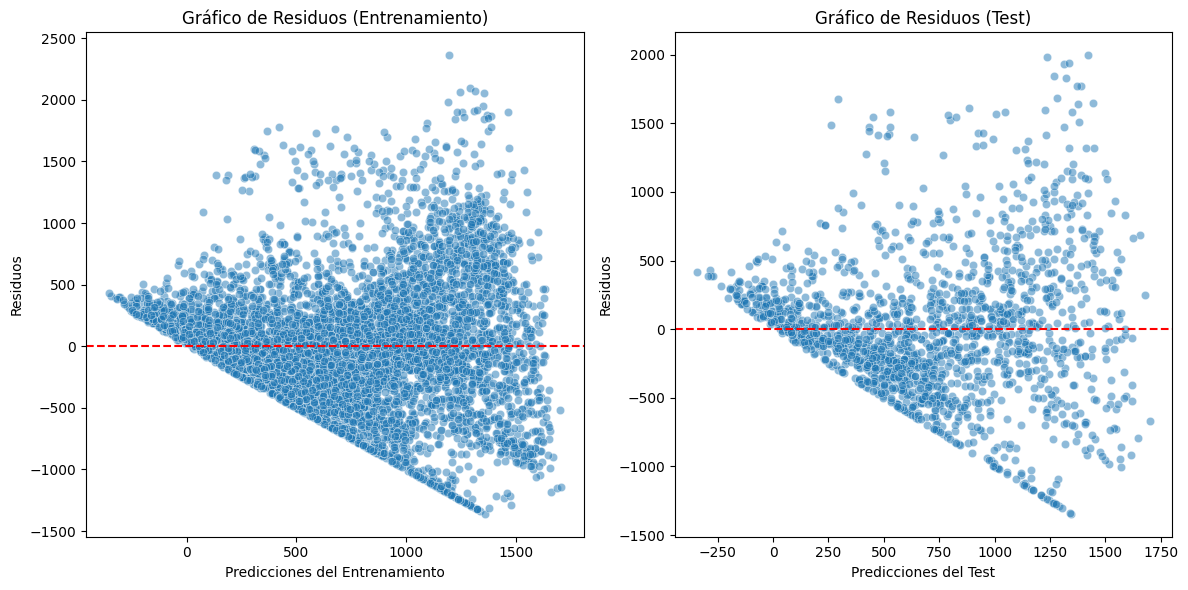

In [136]:
#Distribución Aleatoria: Los residuos deberían estar distribuidos aleatoriamente alrededor de cero. Esto indica que el modelo no tiene patrones sistemáticos de error.
#Patrones o Tendencias: Si observas patrones claros (como una curva), podría indicar que el modelo no está capturando bien la relación entre las variables.


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Suponiendo que ya tienes las predicciones y los valores reales
# y_train_pred y y_train son las predicciones y valores reales del conjunto de entrenamiento
# y_test_pred y y_test son las predicciones y valores reales del conjunto de prueba


# Asegurarse de que las predicciones y los valores reales sean vectores 1D
y_train_Pred = np.ravel(y_train_Pred)
y_test_Pred = np.ravel(y_test_Pred)
y_train = np.ravel(y_train)
y_test = np.ravel(y_test)

# Calcular los residuos
residuals_train = y_train - y_train_Pred
residuals_test = y_test - y_test_Pred

# Crear el gráfico de los residuos para el conjunto de entrenamiento
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_train_Pred, y=residuals_train, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones del Entrenamiento')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos (Entrenamiento)')

# Crear el gráfico de los residuos para el conjunto de prueba
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test_Pred, y=residuals_test, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicciones del Test')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos (Test)')

plt.tight_layout()
plt.show()


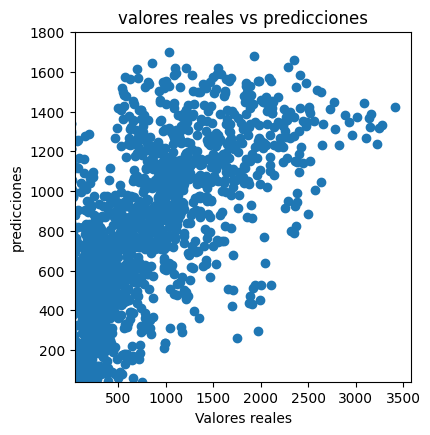

In [137]:
plt.figure(figsize=(20,10))
predicciones = modelo.predict(exog = X_test)
plt.subplot(248)
plt.scatter(y_test, predicciones)
plt.xlabel('Valores reales')
plt.ylabel('predicciones')
plt.title('valores reales vs predicciones')
plt.xlim([40,plt.xlim()[1]])
plt.ylim([40,plt.ylim()[1]])
_ = plt.plot([-100, 120], [-100, 120])

plt.show()

In [138]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_train_const1 = sm.add_constant(X_train)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_train_const1.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const1.values, i) for i in range(X_train_const1.shape[1])]
print(vif_data)


          Variable       VIF
0            const  1.000125
1             Hour  1.032605
2      Temperature  1.152019
3       Visibility  1.029084
4  Solar_Radiation  1.182204


### Revisando Multicolinealidad de Variables

In [163]:
from scipy.stats import shapiro    #normalidad  H0 : Los errores tienen una distribución normal
stat, p = shapiro(modelo.resid)
print('Estadístico=%.3f, p=%.3f' % (stat, p))

from statsmodels.stats.diagnostic import het_breuschpagan   #Homocedasticidad  H: Hay homocedasticidad en los errores
bp_test = het_breuschpagan(modelo.resid, modelo.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

from statsmodels.stats.stattools import durbin_watson    #autocorrelacion  Valor cercano intervalo 1.5 - 2.5
dw = durbin_watson(modelo.resid)
print('Durbin-Watson:', dw)

Estadístico=0.964, p=0.000
{'LM Statistic': np.float64(211.50001107102727), 'LM-Test p-value': np.float64(1.2639329648593365e-44), 'F-Statistic': np.float64(59.96275916853), 'F-Test p-value': np.float64(1.6695327539346618e-47)}
Durbin-Watson: 2.0650067451957557


## Regresion Lineal






In [140]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

In [141]:
#Division de datos en train y test
from sklearn.model_selection import train_test_split
X = df_scaled[['Hour' , 'Temperature' , 'Visibility' , 'Solar_Radiation']]
y = df_scaled['Rented_Bike_Count']

X_train, X_test, y_train, y_test = train_test_split(X, y.values.reshape(-1,1),train_size = 0.8,random_state = 1234,shuffle = True)

In [142]:
lr = LinearRegression()
sfs = SFS(lr,
          k_features='best',
          forward=False,             #pasos hacia atrras
          floating=False,
          scoring='r2',
          cv=5)

sfs = sfs.fit(X_train, y_train)

selected_features = list(sfs.k_feature_names_)
print("Selected features:", selected_features)

Selected features: ['Hour', 'Temperature', 'Visibility']


In [143]:
# Ajustar el modelo y seleccionar características
sfs = sfs.fit(X_train, y_train)
selected_features = list(sfs.k_feature_names_)
print("Selected features:", selected_features)

# Crear subconjuntos de datos con las características seleccionadas
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

# Ajustar el modelo de regresión lineal con las características seleccionadas
final_model = sm.OLS(y_train, sm.add_constant(X_train_selected)).fit()

# Resumen del modelo
print(final_model.summary())

Selected features: ['Hour', 'Temperature', 'Visibility']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     1777.
Date:                Sat, 29 Mar 2025   Prob (F-statistic):               0.00
Time:                        01:56:22   Log-Likelihood:                -53243.
No. Observations:                7008   AIC:                         1.065e+05
Df Residuals:                    7004   BIC:                         1.065e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

In [155]:
# Obtener coeficientes estandarizados
coef_standardized = final_model.params
print("Coeficientes estandarizados:", coef_standardized)

Coeficientes estandarizados: const          701.818781
Hour           215.589992
Temperature    313.993509
Visibility      95.624849
dtype: float64


In [144]:
# Predicción sobre los datos de prueba
y_pred = final_model.predict(sm.add_constant(X_test_selected))

# Evaluación del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Mostrar métricas
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 368.1861426434653
MSE: 251539.74251964106
RMSE: 501.537378985496
R²: 0.4301130009476062


### Regresion Lasso

In [156]:
from sklearn.linear_model import Lasso, Ridge, LassoLarsIC

In [157]:
# Modelo Lasso
lasso_model = Lasso(alpha=1.0,fit_intercept=True )
lasso_model.fit(X_test, y_test)

Lasso()

In [159]:
# Obtener los coeficientes
coeficientes = pd.Series(lasso_model.coef_, index=X_test.columns)
print(coeficientes)
print(f'Intercepto: {lasso_model.intercept_}')

Hour               212.691088
Temperature        319.039353
Visibility          94.599060
Solar_Radiation     31.525234
dtype: float64
Intercepto: [715.48568909]


In [161]:
# Predicciones
y_test_redu_pred = lasso_model.predict(X_test)

# Calcular los indicadores de calidad
mae = mean_absolute_error(y_test, y_test_redu_pred)
mse = mean_squared_error(y_test, y_test_redu_pred)
rmse = np.sqrt(mse)
#mape = mean_absolute_percentage_error(y_test, y_test_redu_pred)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
#print(f'MAPE: {mape}')

MAE: 367.95023218939355
MSE: 250200.92860320988
RMSE: 500.20088824712207


## Regresion - Regularización Ridge

In [149]:
# Ajustar el modelo Ridge
ridge = Ridge(alpha=1.0)  # Puedes ajustar el valor de alpha según sea necesario
ridge.fit(X_test, y_test)

# Obtener los coeficientes
coeficientes = pd.Series(ridge.coef_, index=X_test.columns)
print(coeficientes)
print(f'Intercepto: {ridge.intercept_}')

Hour               213.321326
Temperature        319.547909
Visibility          95.308392
Solar_Radiation     32.157965
dtype: float64
Intercepto: [715.51564482]


In [150]:
# Predicciones
y_pred_Ridge = ridge.predict(X_test)

# Calcular los indicadores de calidad
mae = mean_absolute_error(y_test, y_pred_Ridge)
mse = mean_squared_error(y_test, y_pred_Ridge)
rmse = np.sqrt(mse)
#mape = mean_absolute_percentage_error(y_test, y_pred_Ridge)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')


MAE: 368.01973457070665
MSE: 250198.22763217156
RMSE: 500.19818835354806


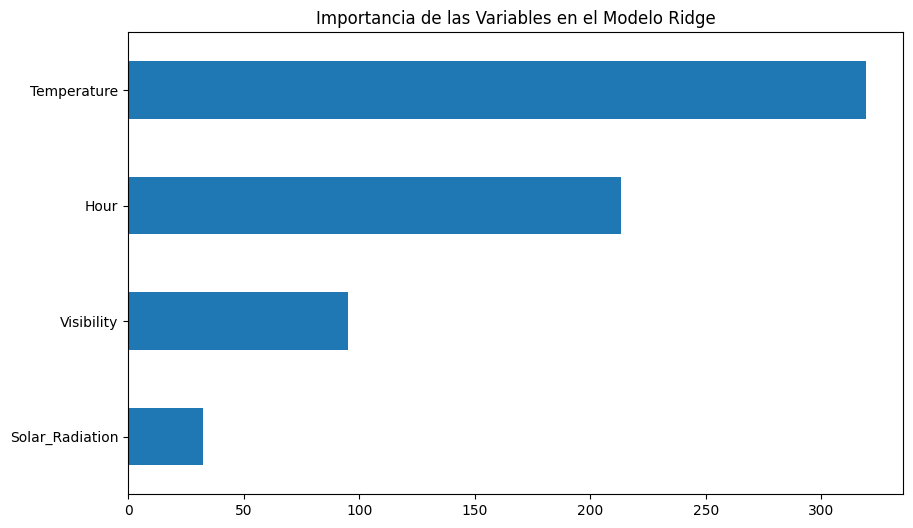

In [151]:
# Importancia de las variables
importancia = pd.Series(ridge.coef_, index=X_test.columns)
importancia = importancia.sort_values()

# Graficar la importancia de las variables
plt.figure(figsize=(10, 6))
importancia.plot(kind='barh')
plt.title('Importancia de las Variables en el Modelo Ridge')
plt.show()


## Elastic Net

In [152]:
from sklearn.linear_model import ElasticNet
# Ajustar el modelo Elastic Net
elastic_net = ElasticNet(alpha=1.0, l1_ratio=0.5)  # Puedes ajustar alpha y l1_ratio según sea necesario
elastic_net.fit(X_test, y_test)

# Obtener los coeficientes
coeficientes = pd.Series(elastic_net.coef_, index=X_test.columns)
print(coeficientes)
print(f'Intercepto: {elastic_net.intercept_}')


Hour               150.659646
Temperature        212.769555
Visibility          70.362774
Solar_Radiation     53.907192
dtype: float64
Intercepto: [713.8576692]


In [153]:
# Predicciones
y_pred_elastic = elastic_net.predict(X_test)

# Calcular los indicadores de calidad
mae = mean_absolute_error(y_test, y_pred_elastic)
mse = mean_squared_error(y_test, y_pred_elastic)
rmse = np.sqrt(mse)
#mape = mean_absolute_percentage_error(y_test, y_pred)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')


MAE: 381.24229143842155
MSE: 266683.94013335096
RMSE: 516.414504185689
